In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from pypfopt import EfficientFrontier, risk_models, expected_returns

In [2]:
tickers = ["TSLA", "SPY", "BND"]

df = yf.download(tickers, start="2015-01-01", end="2026-06-30")["Close"]

df.head()

[*********************100%***********************]  3 of 3 completed


Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,59.405418,169.687820,14.620667
2015-01-05,59.577908,166.623306,14.006000
2015-01-06,59.750401,165.053925,14.085333
2015-01-07,59.786346,167.110672,14.063333
2015-01-08,59.692924,170.076050,14.041333


In [3]:
returns = df.pct_change().dropna()

returns.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-05,0.002904,-0.018060,-0.042041
2015-01-06,0.002895,-0.009419,0.005664
2015-01-07,0.000602,0.012461,-0.001562
2015-01-08,-0.001563,0.017745,-0.001564
2015-01-09,0.001685,-0.008013,-0.018802


In [4]:
mu = expected_returns.mean_historical_return(df)

In [5]:
S = risk_models.sample_cov(df)

In [6]:
ef = EfficientFrontier(mu, S)

weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

cleaned_weights

OrderedDict([('BND', 0.55849), ('SPY', 0.3879), ('TSLA', 0.05361)])

In [7]:
performance = ef.portfolio_performance(verbose=True)

Expected annual return: 8.2%
Annual volatility: 9.6%
Sharpe Ratio: 0.86


In [8]:
ef2 = EfficientFrontier(mu, S)
min_vol_weights = ef2.min_volatility()
ef2.clean_weights()

OrderedDict([('BND', 0.94538), ('SPY', 0.05462), ('TSLA', 0.0)])

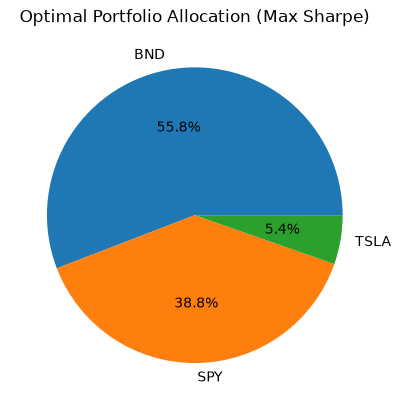

In [9]:
pd.Series(cleaned_weights).plot(kind="pie", autopct="%1.1f%%")
plt.title("Optimal Portfolio Allocation (Max Sharpe)")
plt.show()

In [10]:
print("Max Sharpe Weights:", cleaned_weights)
print("Min Vol Weights:", min_vol_weights)

Max Sharpe Weights: OrderedDict({'BND': 0.55849, 'SPY': 0.3879, 'TSLA': 0.05361})
Min Vol Weights: OrderedDict({'BND': 0.9453841027959708, 'SPY': 0.0546158972040293, 'TSLA': 0.0})
